In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df=pd.read_csv(r"..\CIC-IDS2017-Dataset\WebAttacks-Thursday-no-metadata.parquet.csv")

In [3]:
#Statistical Summary
df.describe()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,155820.000000,1.558200e+05,155820.000000,155820.000000,1.558200e+05,1.558200e+05,155820.000000,155820.000000,155820.000000,155820.000000,...,155820.000000,155820.000000,1.558200e+05,1.558200e+05,1.558200e+05,1.558200e+05,1.558200e+05,1.558200e+05,1.558200e+05,1.558200e+05
mean,11.564003,1.359149e+07,16.359126,19.644115,6.041778e+02,3.480100e+04,180.784790,23.772629,50.893888,50.518067,...,12.967604,25.627352,8.127759e+04,5.112552e+04,1.800117e+05,5.480641e+04,4.025527e+06,1.433082e+05,4.128616e+06,3.864536e+06
std,5.507971,3.314022e+07,1174.352733,1562.683713,8.060422e+03,3.618735e+06,478.328844,39.158784,96.360875,144.787326,...,1127.082620,6.387760,6.459800e+05,3.855086e+05,1.039984e+06,5.860474e+05,1.351013e+07,1.812403e+06,1.378406e+07,1.336012e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.000000,2.280000e+02,1.000000,1.000000,4.300000e+01,1.800000e+01,31.000000,0.000000,21.666666,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,17.000000,4.786450e+04,2.000000,2.000000,7.100000e+01,1.560000e+02,43.000000,27.000000,39.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,17.000000,2.878910e+06,4.000000,2.000000,1.760000e+02,3.690000e+02,70.000000,42.000000,51.000000,21.920311,...,3.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,17.000000,1.200000e+08,200755.000000,270686.000000,1.197199e+06,6.270000e+08,23360.000000,1729.000000,4183.057000,5463.493700,...,192491.000000,60.000000,1.030000e+08,6.370000e+07,1.030000e+08,1.030000e+08,1.200000e+08,7.260000e+07,1.200000e+08,1.200000e+08


In [4]:
#Data Cleaning 
# Removing missing values
print(df.isnull().sum())

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64


In [5]:
# Removing infinity values
df.replace([np.inf,-np.inf],
np.nan,inplace=True)
df.dropna(inplace=True)

In [6]:
#Remove Duplicates
print("Duplicate Rows:",df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate Rows: 0


In [7]:
# Verifying Attacks Label
print(df["Label"].value_counts())

Label
Benign                        153677
Web Attack � Brute Force        1470
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_24692\2770178209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


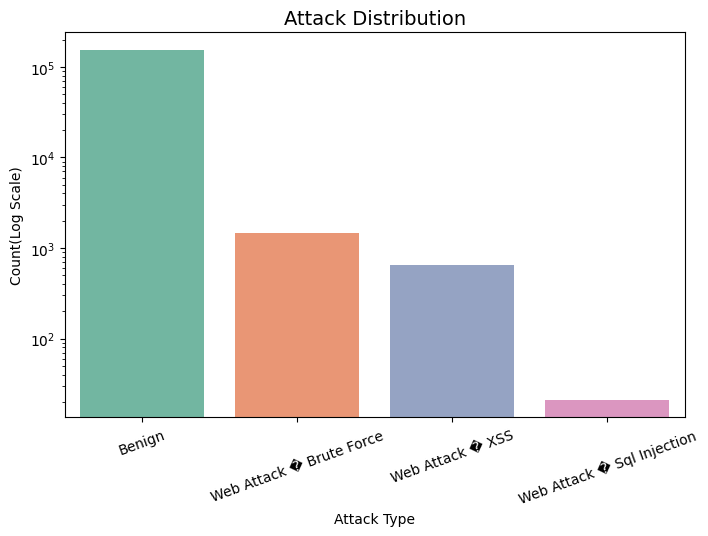

In [8]:
# EDA (Attack Distribution)
plt.figure(figsize=(8,5))
sns.countplot(
    x="Label",
    data=df,
    order=df["Label"].value_counts().index,
    palette="Set2"
)
plt.yscale("log")
plt.xticks(rotation=20)
plt.title("Attack Distribution",fontsize=14)
plt.xlabel("Attack Type")
plt.ylabel("Count(Log Scale)")
plt.show()

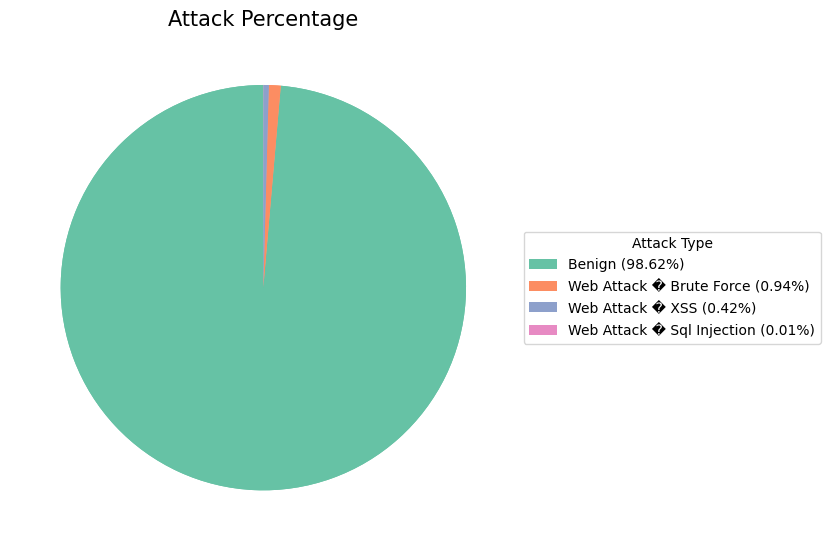

In [9]:
# Attack Percentage
attack_percent=df["Label"].value_counts()
colors=sns.color_palette("Set2")
percentage=(attack_percent/attack_percent.sum()*100).round(2)
legend_labels=[f"{label} ({pct}%)" for label ,pct in zip(attack_percent.index,percentage)]
plt.figure(figsize=(8,7))
wedges,texts=plt.pie(
    attack_percent,
    colors=colors,
    startangle=90
)
plt.pie(
    attack_percent,
    colors=colors,
    startangle=90
)
plt.title("Attack Percentage",fontsize=15)
plt.legend(
    wedges,
    legend_labels,
    title="Attack Type",
    loc="center left",
    bbox_to_anchor=(1,0.5)
)
plt.tight_layout()
plt.show()

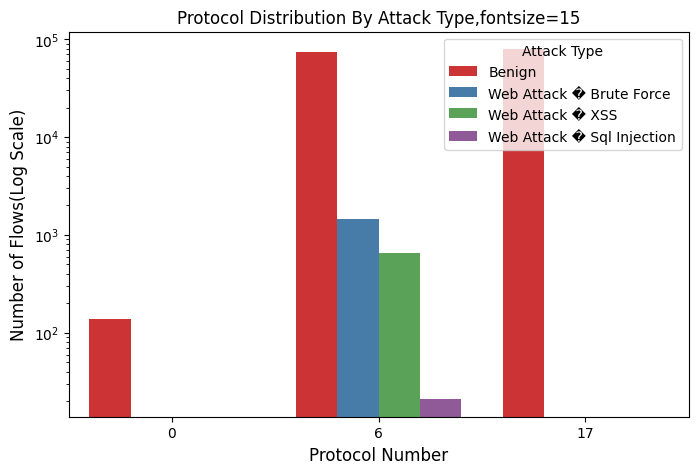

In [10]:
# Protocol Distribution 
plt.figure(figsize=(8,5))
sns.countplot(
    x="Protocol",
    hue="Label",
    data=df,
    palette="Set1"
)
plt.yscale("log")
plt.xlabel("Protocol Number",fontsize=12)
plt.ylabel("Number of Flows(Log Scale)",fontsize=12)
plt.title("Protocol Distribution By Attack Type,fontsize=15")
plt.legend(title="Attack Type")
plt.show()

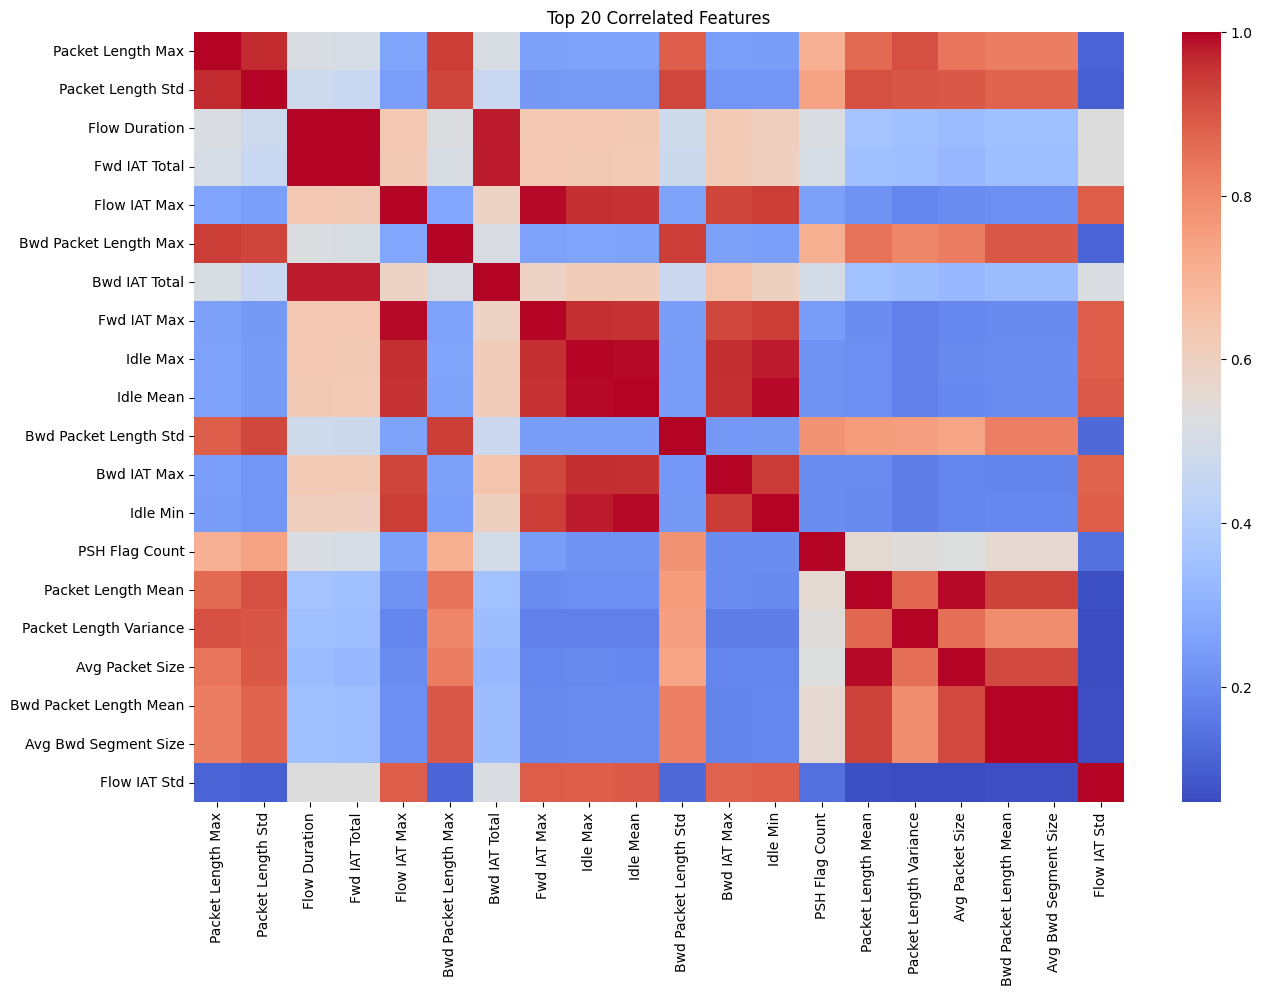

In [11]:
# Correlation Heatmap
numeric_df=df.select_dtypes(include=np.number)
corr=numeric_df.corr()
top20=corr.abs().sum().sort_values(ascending=False).head(20).index
plt.figure(figsize=(15,10))
sns.heatmap(
    numeric_df[top20].corr(),annot=False,cmap="coolwarm"
)
plt.title("Top 20 Correlated Features")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24692\2313120968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


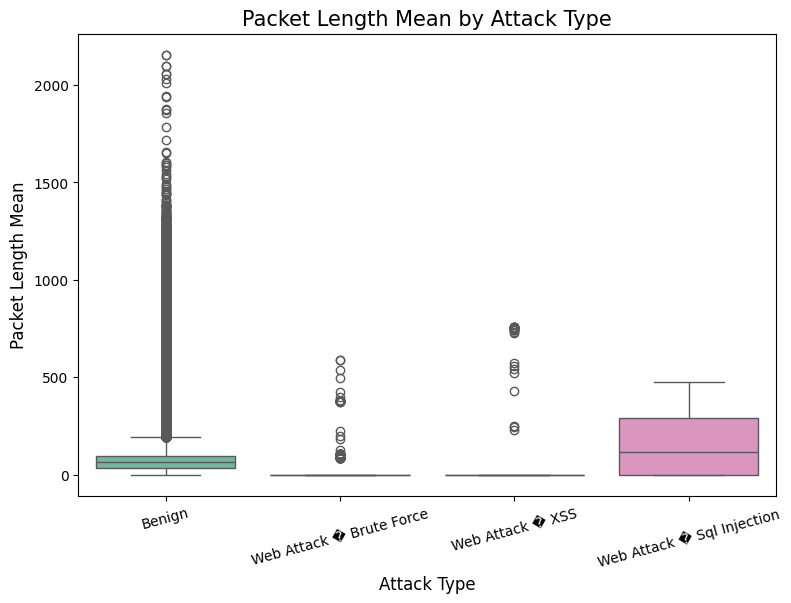

In [12]:
# Payload Analysis(Boxplot)
plt.figure(figsize=(9,6))
sns.boxplot(
    data=df,
    x="Label",
    y="Packet Length Mean",
    palette="Set2"
)
plt.title("Packet Length Mean by Attack Type",fontsize=15)
plt.xlabel("Attack Type",fontsize=12)
plt.ylabel("Packet Length Mean",fontsize=12)
plt.xticks(rotation=15)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24692\796341883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


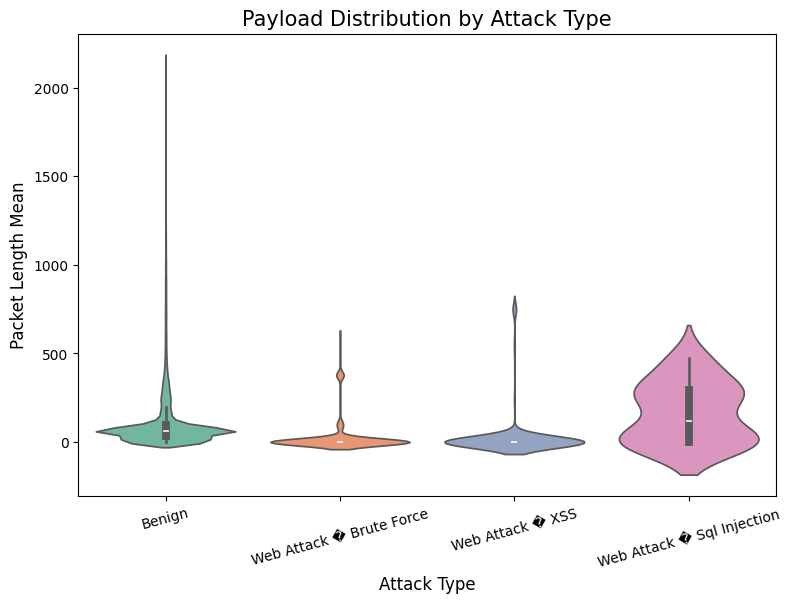

In [13]:
#Violin Plot
plt.figure(figsize=(9,6))
sns.violinplot(
    data=df,
    x="Label",
    y="Packet Length Mean",
    palette="Set2"
)
plt.title("Payload Distribution by Attack Type",fontsize=15)
plt.xlabel("Attack Type",fontsize=12)
plt.ylabel("Packet Length Mean",fontsize=12)
plt.xticks(rotation=15)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24692\1314876423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


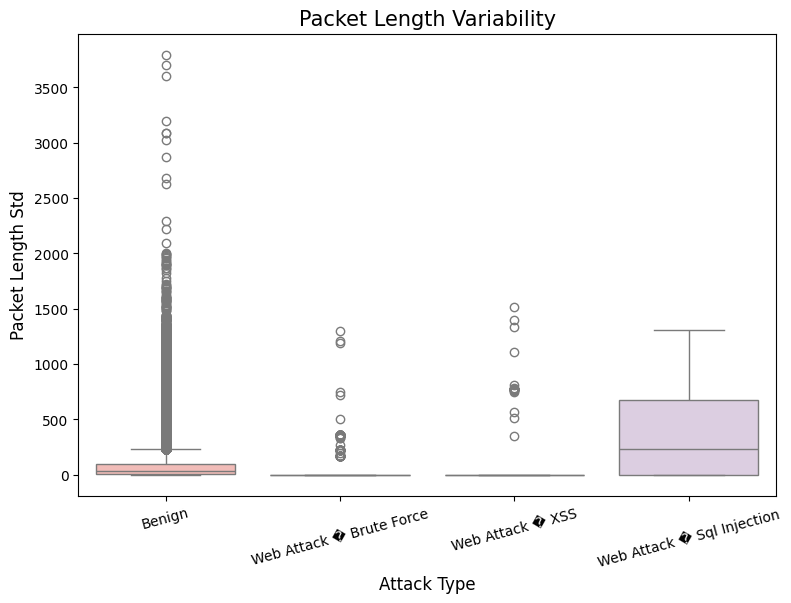

In [14]:
# Packet Variability
plt.figure(figsize=(9,6))
sns.boxplot(
    data=df,
    x="Label",
    y="Packet Length Std",
    palette="Pastel1"
)
plt.title("Packet Length Variability",fontsize=15)
plt.xlabel("Attack Type",fontsize=12)
plt.ylabel("Packet Length Std",fontsize=12)
plt.xticks(rotation=15)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24692\728175550.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


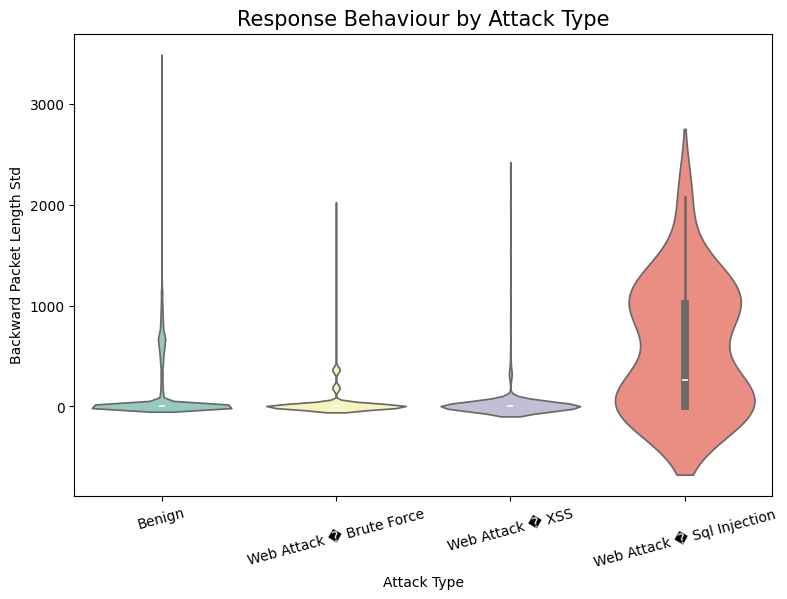

In [15]:
# Responsive Behaviour 
plt.figure(figsize=(9,6))
sns.violinplot(
    data=df,
    x="Label",
    y="Bwd Packet Length Std",
    palette="Set3"
)
plt.title("Response Behaviour by Attack Type",fontsize=15)
plt.xlabel("Attack Type")
plt.ylabel("Backward Packet Length Std")
plt.xticks(rotation=15)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24692\512313840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


([0, 1, 2, 3],
 [Text(0, 0, 'Benign'),
  Text(1, 0, 'Web Attack � Brute Force'),
  Text(2, 0, 'Web Attack � XSS'),
  Text(3, 0, 'Web Attack � Sql Injection')])

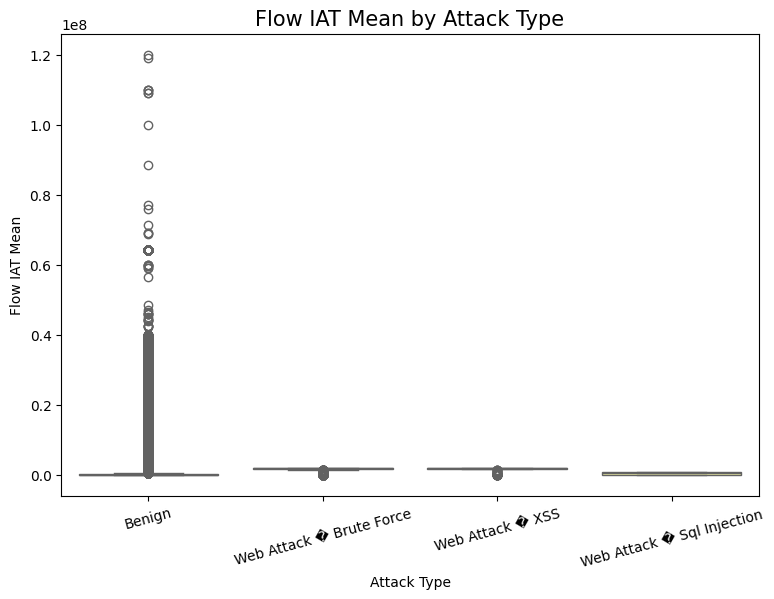

In [16]:
# Packet Timing 
plt.figure(figsize=(9,6))
sns.boxplot(
    data=df,
    x="Label",
    y="Flow IAT Mean",
    palette="Accent"
)
plt.title("Flow IAT Mean by Attack Type",fontsize=15)
plt.xlabel("Attack Type")
plt.ylabel("Flow IAT Mean")
plt.xticks(rotation=15)

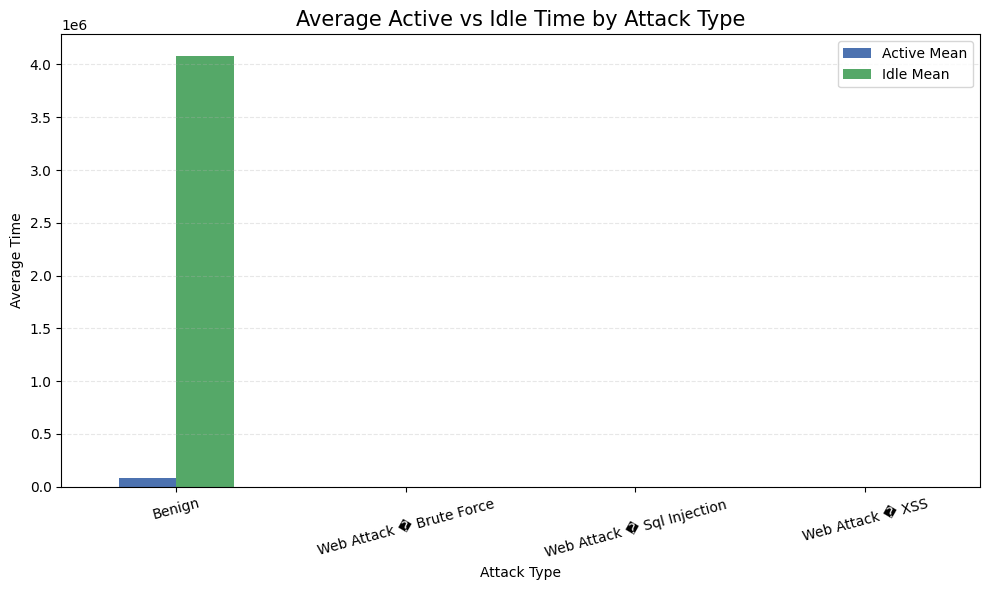

In [17]:
#Active vs Idle Analysis
avg_time=df.groupby("Label")[["Active Mean","Idle Mean"]].mean().reset_index()
avg_time.plot(
    x="Label",
    kind="bar",
    figsize=(10,6),
    color=["#4C72B0","#55A868"]
)
plt.title("Average Active vs Idle Time by Attack Type",fontsize=15)
plt.xlabel("Attack Type")
plt.ylabel("Average Time")
plt.xticks(rotation=15)
plt.grid(axis="y",linestyle="--",alpha=0.3)
plt.tight_layout()
plt.show()